In [2]:
import pandas as pd

df= pd.read_csv('Dale-medical-center_standardcharges.csv',skiprows = 2)
print(df.head(7))

                       description code|1 code|1|type  code|2 code|2|type  \
0  ZEPHIRAN SOL(BENZALKONIUM):8 OZ    250          RC     NaN         NaN   
1                    RECOVERY ROOM    710          RC     NaN         NaN   
2             REC ROOM ADD HALF HR    710          RC     NaN         NaN   
3                         ARMBOARD    270          RC     NaN         NaN   
4                        BLOOD SET    270          RC     NaN         NaN   
5                 CONNECTOR TUBING    270          RC     NaN         NaN   
6                     IV START KIT    270          RC     NaN         NaN   

   modifiers  drug_unit_of_measurement  drug_type_of_measurement setting  \
0        NaN                       NaN                       NaN    both   
1        NaN                       NaN                       NaN    both   
2        NaN                       NaN                       NaN    both   
3        NaN                       NaN                       NaN    both   
4  

In [3]:
df.isnull().sum()

description                                                                         0
code|1                                                                              0
code|1|type                                                                         0
code|2                                                                           7426
code|2|type                                                                      7426
modifiers                                                                        9612
drug_unit_of_measurement                                                         9612
drug_type_of_measurement                                                         9612
setting                                                                             0
standard_charge|gross                                                               0
standard_charge|discounted_cash                                                     0
standard_charge|Aetna|Default|methodology             

In [6]:
#df = df.dropna(how='all',axis=1)
#print(df)
df.isnull().sum()

description                                                                        0
code|1                                                                             0
code|1|type                                                                        0
code|2                                                                          7426
code|2|type                                                                     7426
setting                                                                            0
standard_charge|gross                                                              0
standard_charge|discounted_cash                                                    0
standard_charge|Aetna|Default|methodology                                          0
standard_charge|Aetna|Default|negotiated_dollar                                    1
standard_charge|Blue Cross Blue Shield of AL|Default|methodology                   0
standard_charge|Blue Cross Blue Shield of AL|Default|negotiated_d

In [4]:
#defining the columns I want to keep
cols_to_keep = ['description','standard_charge|min','standard_charge|max']
df_final = df[cols_to_keep].copy()
df_final = df_final.rename(columns = { 'description': 'Item', 'standard_charge|min': 'Min_price','standard_charge|max': 'Max_price'})
print(df_final.head(5))

                              Item  Min_price  Max_price
0  ZEPHIRAN SOL(BENZALKONIUM):8 OZ      52.06      73.06
1                    RECOVERY ROOM     374.54     525.67
2             REC ROOM ADD HALF HR      63.86      89.63
3                         ARMBOARD      15.98      22.43
4                        BLOOD SET      23.97      33.64


In [5]:
median_price = df_final['Max_price'].median()
print(median_price)

39.265


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import numpy as np
import pandas as pd
df_final['expensive'] = (df_final['Max_price'] > median_price).astype(int)
custom_stops = list(TfidfVectorizer(stop_words='english').get_stop_words()) + ['tab','tablet','cap','capsule']
vectorizer = TfidfVectorizer( stop_words = custom_stops,max_features=500,analyzer='word',token_pattern=r'\b[a-zA-Z]{3,}\b',min_df=5,ngram_range=(1,2))
X_text = vectorizer.fit_transform(df_final['Item'])
y = df_final['expensive']

#Split data

X_train, X_test , y_train, y_test = train_test_split(X_text, y, test_size = 0.2, random_state = 42)
#Train Model

model = RandomForestClassifier(n_estimators = 200, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")
print (classification_report(y_test, predictions))

feature_names = vectorizer.get_feature_names_out()
importances = model.feature_importances_
top_indices = importances.argsort()[-20:][::-1]

for i in top_indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

print(df_final[df_final['Item'].str.contains('tab',case= False)].groupby('expensive')['expensive'].count())
                                                     

Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.67      0.84      0.75       953
           1       0.79      0.60      0.68       970

    accuracy                           0.72      1923
   macro avg       0.73      0.72      0.71      1923
weighted avg       0.73      0.72      0.71      1923

oral: 0.0728
hcl: 0.0283
screw: 0.0134
suture: 0.0130
inj: 0.0113
implant: 0.0112
mesh: 0.0111
bone: 0.0110
liq: 0.0109
kit: 0.0101
right: 0.0093
tray: 0.0089
mri: 0.0087
stent: 0.0083
blade: 0.0081
left: 0.0079
status: 0.0076
opth: 0.0072
trocar: 0.0070
solution: 0.0069
expensive
0    1577
1     201
Name: expensive, dtype: int64


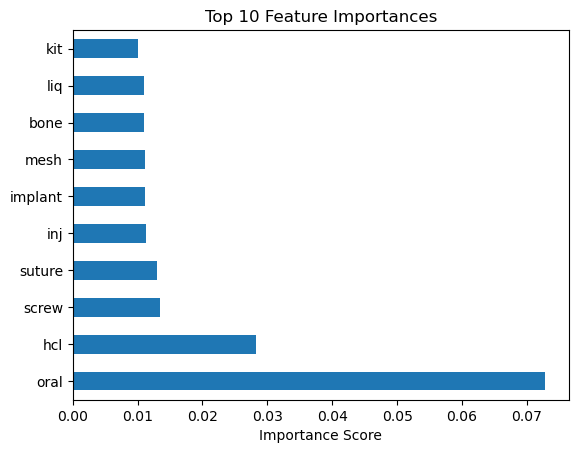

In [21]:
# What features mattered most?
import pandas as pd
import matplotlib.pyplot as plt
feat_importances = pd.Series(model.feature_importances_,index=feature_names)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.show()